In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\Harshitha\Downloads\Sample - Superstore.csv.zip",encoding="latin1")

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
data.shape

(9994, 21)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
total_sales = data["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 2297200.8603


In [9]:
total_profit = data["Profit"].sum()
print("Total Profit: ", total_profit)

Total Profit:  286397.0217


In [10]:
total_quantity = data["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 37873


In [11]:
total_orders = data["Order ID"].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


In [12]:
print("Total Sales:", data["Sales"].sum())
print("Total Profit:", data["Profit"].sum())
print("Total Quantity:", data["Quantity"].sum())
print("Total Orders:", data["Order ID"].nunique())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity: 37873
Total Orders: 5009


In [14]:
data["Order Date"] = pd.to_datetime(data["Order Date"])

In [17]:
data["Year"] = data["Order Date"].dt.year

In [18]:
data[["Order Date", "Year"]].head()

,Order Date,Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [19]:
yearly_sales = data.groupby("Year")["Sales"].sum()

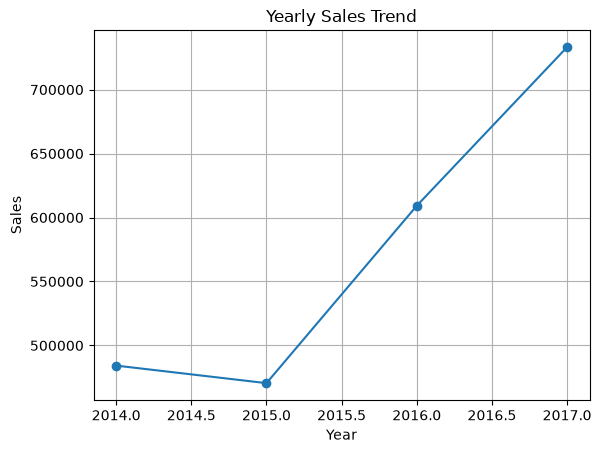

In [20]:
yearly_sales.plot(kind="line", marker="o")

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [21]:
top_products = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)
print(top_products.head(10))

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


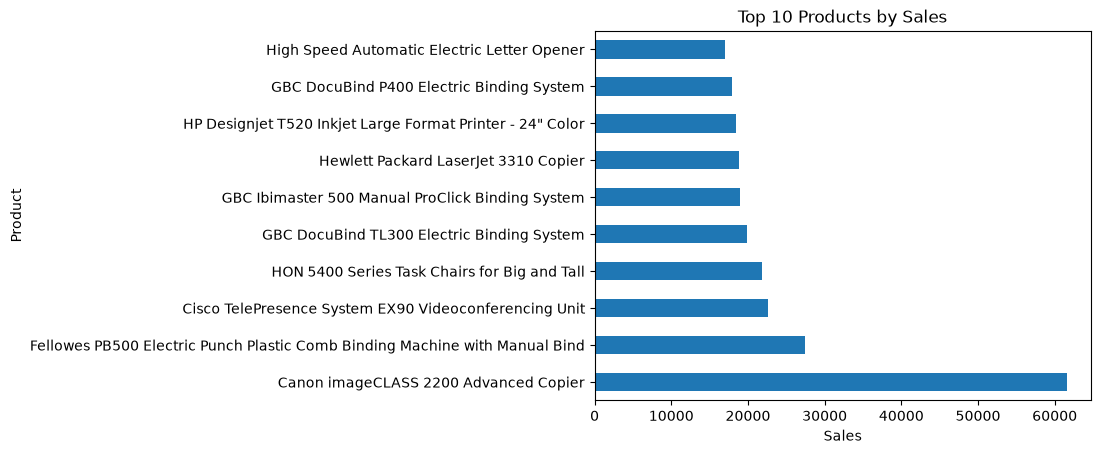

In [22]:
top_10 = top_products.head(10)

top_10.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()


In [23]:
category_sales = data.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


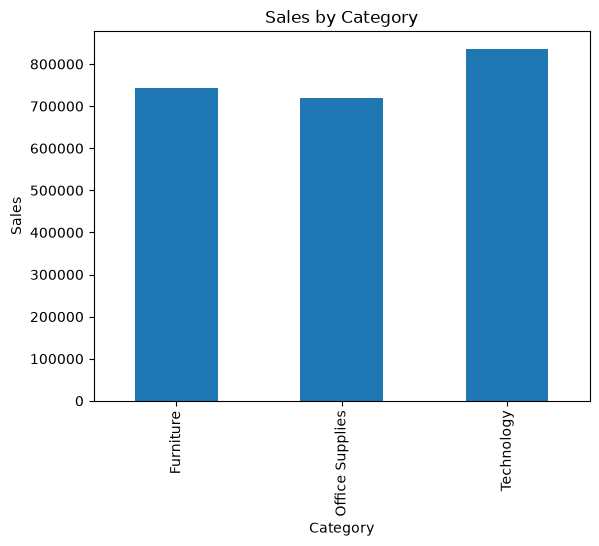

In [24]:
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [25]:
category_profit = data.groupby("Category")["Profit"].sum()
print(category_profit)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


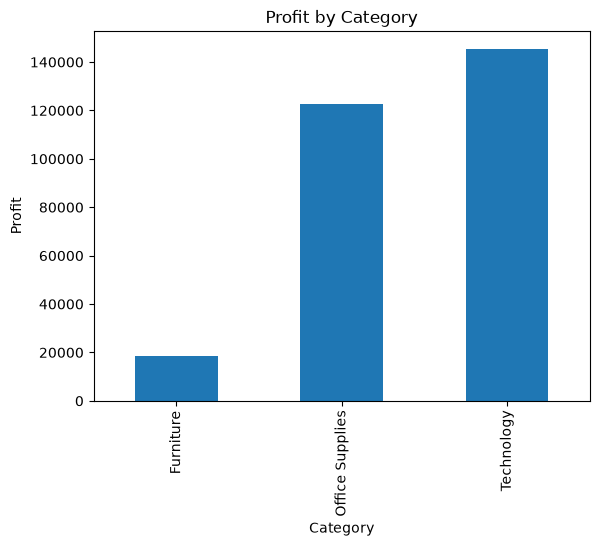

In [26]:
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [27]:
region_sales = data.groupby("Region")["Sales"].sum()
print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


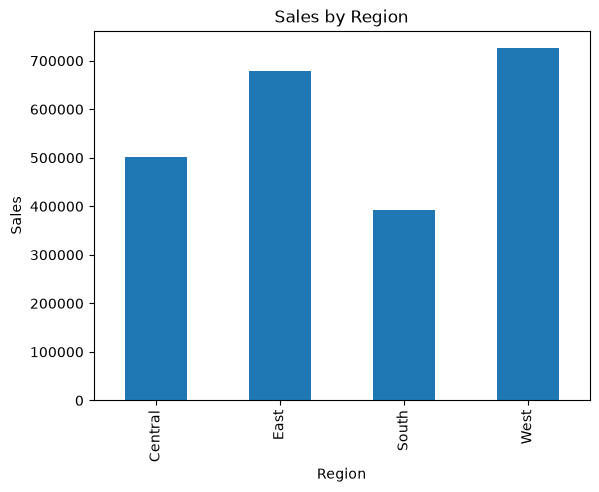

In [28]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [30]:
region_profit = data.groupby("Region")["Profit"].sum()
print(region_profit)                                                     

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


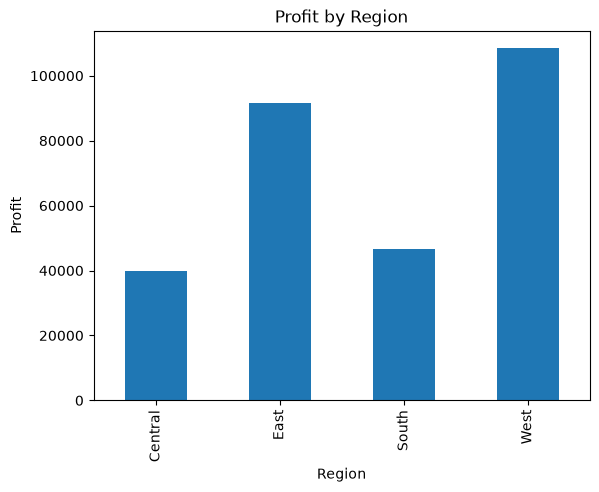

In [31]:
region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [34]:
subcategory_sales = data.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [35]:
print(subcategory_sales.head(10))

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


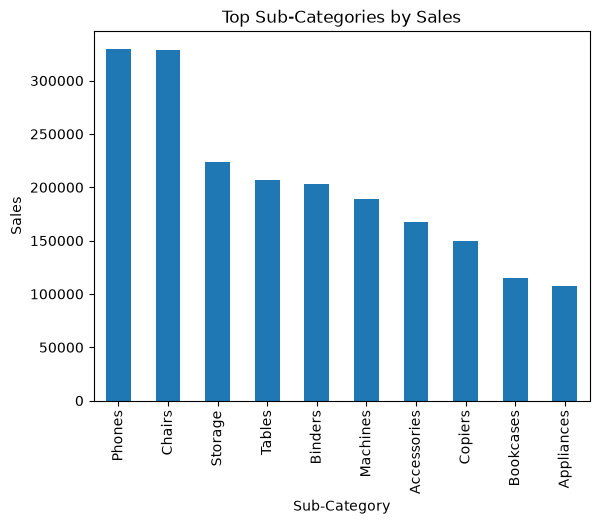

In [36]:
subcategory_sales.head(10).plot(kind="bar")

plt.title("Top Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.show()

In [38]:
subcategory_profit = data.groupby("Sub-Category")["Profit"].sum().sort_values()

print(subcategory_profit)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


In [39]:
loss_making = subcategory_profit[subcategory_profit < 0]
print(loss_making)

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


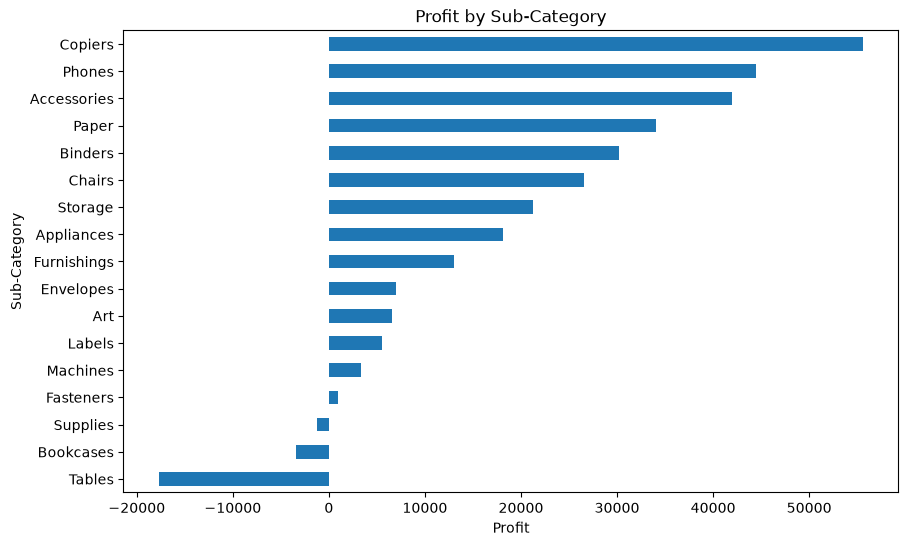

In [42]:
subcategory_profit.plot(kind="barh", figsize=(10,6))

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.show()

In [43]:
data["Month"] = data["Order Date"].dt.month

In [45]:
monthly_sales = data.groupby("Month")["Sales"].sum()

print(monthly_sales)

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


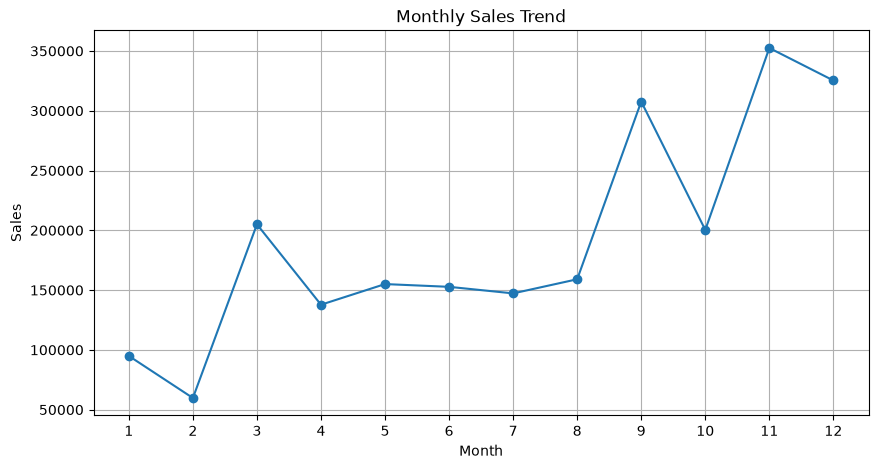

In [46]:
monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1,13))

plt.grid(True)
plt.show()

In [48]:
data["Year_Month"] = data["Order Date"].dt.to_period("M")

In [49]:
data["Year_Month"] = data["Order Date"].dt.to_period("M")

In [50]:
year_month_sales = data.groupby("Year_Month")["Sales"].sum()
print(year_month_sales)

Year_Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


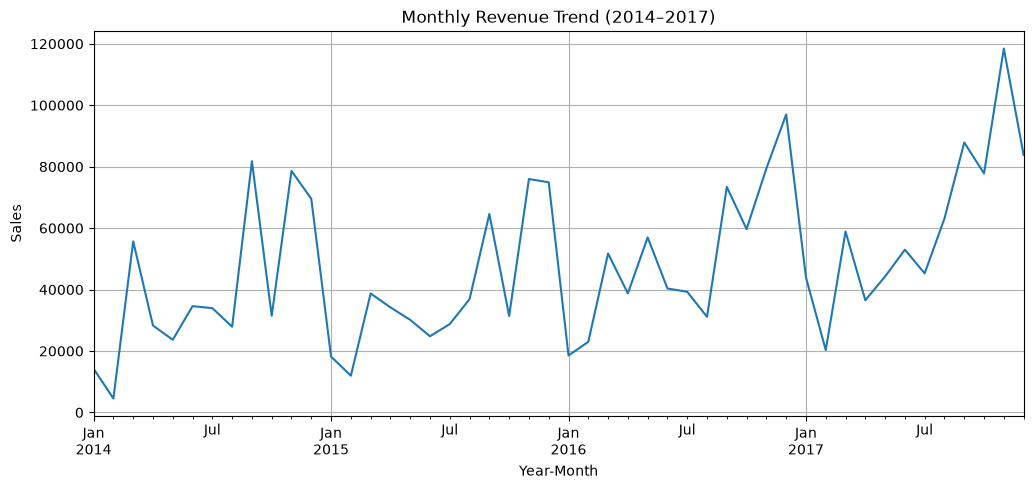

In [51]:
year_month_sales.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend (2014–2017)")
plt.xlabel("Year-Month")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

In [52]:
category_performance = data.groupby("Category")[["Sales", "Profit"]].sum()

print(category_performance)

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


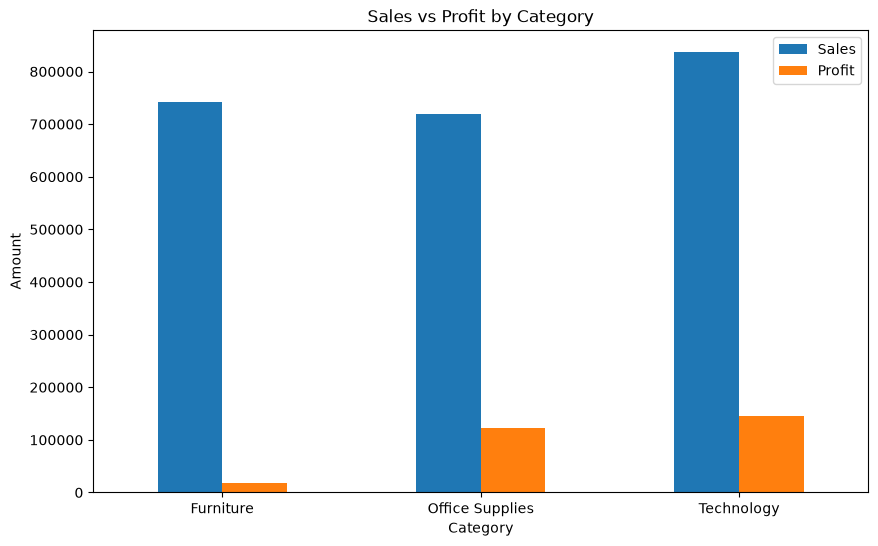

In [53]:
category_performance.plot(kind="bar", figsize=(10,6))

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])

plt.show()

In [54]:
category_performance["Profit Margin (%)"] = (
    category_performance["Profit"] /
    category_performance["Sales"]
) * 100

print(category_performance)

                       Sales       Profit  Profit Margin (%)
Category                                                    
Furniture        741999.7953   18451.2728           2.486695
Office Supplies  719047.0320  122490.8008          17.035158
Technology       836154.0330  145454.9481          17.395712


In [56]:
discount_analysis = (
    data.groupby("Discount")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

discount_analysis

,Discount,Sales,Profit,Quantity
0,0.00,1.087908e+06,320987.6032,18267
1,0.10,5.436935e+04,9029.1770,373
2,0.15,2.755852e+04,1418.9915,198
3,0.20,7.645944e+05,90337.3060,13660
4,0.30,1.032267e+05,-10369.2774,849
5,0.32,1.449346e+04,-2391.1377,105
6,0.40,1.164178e+05,-23057.0504,786
7,0.45,5.484974e+03,-2493.1111,45
8,0.50,5.891854e+04,-20506.4281,241
9,0.60,6.644700e+03,-5944.6552,501


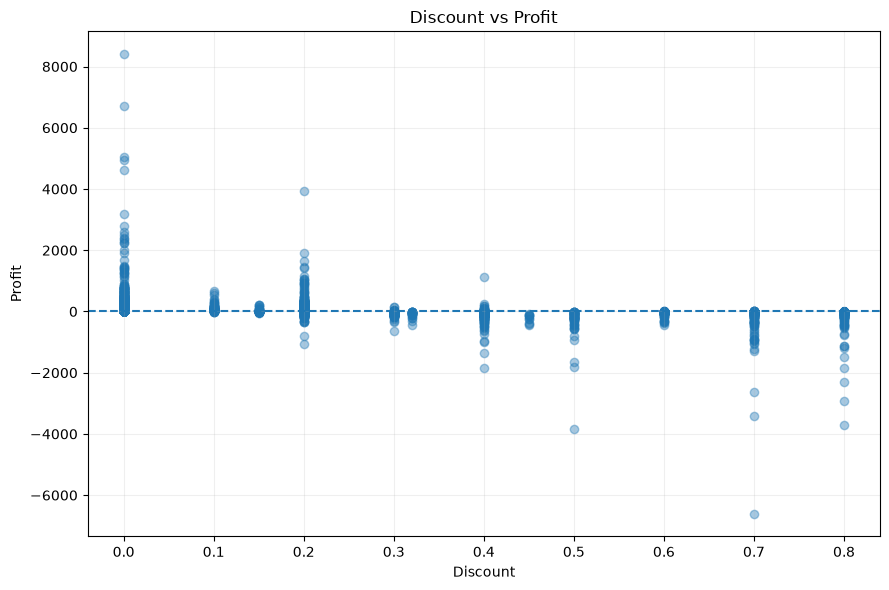

In [57]:
plt.figure(figsize=(9, 6))

plt.scatter(
    data["Discount"],
    data["Profit"],
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.axhline(0, linestyle="--")

plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()